In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib inline

import os
while 'notebooks' in os.getcwd():
    os.chdir("../")

!pwd

/Users/msat/projects/SemanticPullbacks


In [2]:
import platform
platform.machine()

'arm64'

In [3]:
import torch
import math
from torch import nn, einsum
from torchvision.datasets import Imagenette
from torch.utils.data import DataLoader

import torch.nn.functional as F
from torchvision import transforms as T

from lib.dataset import get_imagenette, get_imagenet, get_examples, FromMyNormalizeToImageNet, ImagenetToImagenetteHead, wrap_imagenet_model
from lib.pga import PGA
from lib.helpers import plot_example_grid, plot_function, show_images
from lib.surrogates import soften_module_inplace_, set_module_standard_backward_
from lib.attributions import LocalGradientAscent, LocalRelevanceAscent

In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
device = torch.device(device)
device

device(type='mps')

In [5]:
# dataset = "imagenet"
dataset = "imagenette"

if dataset == "imagenet":
    dataset = get_imagenet()
elif dataset == "imagenette":
    try:
        dataset = get_imagenette(download=True)
    except RuntimeError as e:
        # wierdly, Imagenette raises error if already downloaded (at least in some torchvision versions)
        print(e)
        dataset = get_imagenette(download=False)

seed = 314
generator = torch.Generator().manual_seed(seed)
loader = DataLoader(dataset, batch_size=5, shuffle=True, generator=generator)

In [6]:
it = iter(loader)

tensor(-1.) tensor(1.) tensor(-0.1629) tensor(0.4621)
images.shape = torch.Size([5, 3, 224, 224])
labels = [4, 5, 7, 2, 9]


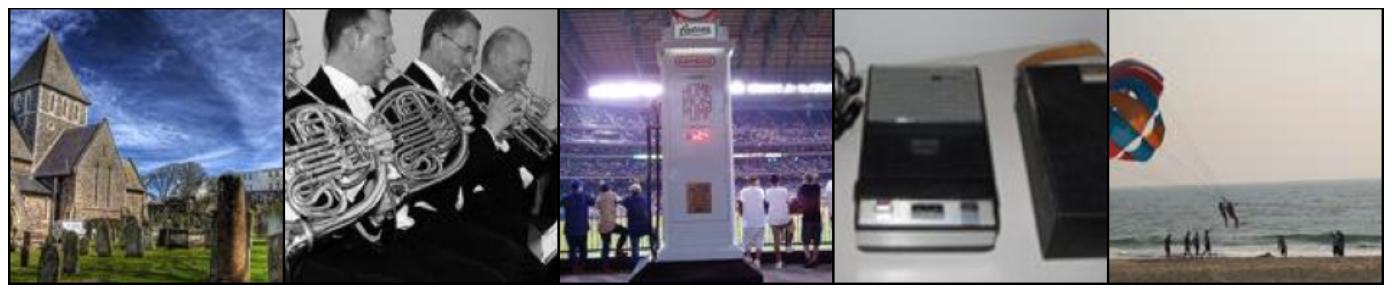

In [7]:
# images, labels = next(iter(loader))
images, labels = next(it)

print(images.min(), images.max(), images.mean(), images.std())
print(f"images.shape = {images.shape}")
print(f"labels = {labels.tolist()}")

plot_example_grid(images, nrow=5)

In [8]:
from torchvision.models import resnet50, resnet18, vgg11_bn, densenet121, vit_b_16, convnext_tiny, efficientnet_b0, resnet18, squeezenet1_1, resnext50_32x4d

model_cls = resnet18
# model_cls = resnet50
# model_cls = densenet121
# model_cls = vgg11_bn
# model_cls = vit_b_16
# model_cls = resnet18
# model_cls = efficientnet_b0
# model_cls = squeezenet1_1
# model_cls = convnext_tiny
# model_cls = resnext50_32x4d

# backbone_std = model_cls(pretrained=True)
backbone = model_cls(pretrained=True)
model = wrap_imagenet_model(backbone)
model = model.to(device)
model.eval()
pass

/Users/msat/.venvs/quantus/lib/python3.14/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/msat/.venvs/quantus/lib/python3.14/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
images = images.to(device)
labels = labels.to(device)

In [10]:
orig_res = model(images)#.shape

In [ ]:
lga = LocalGradientAscent(model, alpha=None, steps=1, eps=None)

Attack mode is changed to 'targeted(label)'.


In [ ]:
orig_grads = lga.attribute(images, target=labels)

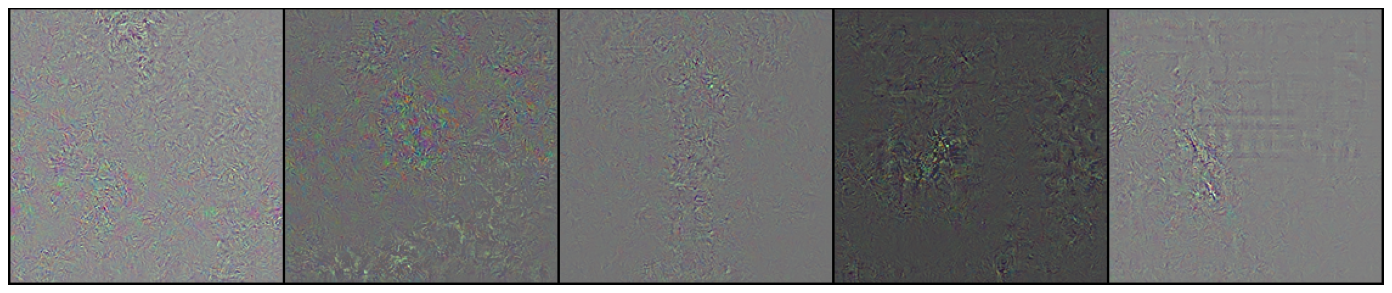

In [13]:
plot_example_grid(orig_grads, nrow=5)

In [14]:
lga.model[1].layer3, lga.model[1].maxpool, model.training

(Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): Batc

In [15]:
temperatures = {
    "ReLU": 0.3,
    "SiLU": 0.6,
    "GELU": 1.0,
    "MaxPool2d": 0.2,
    "MultiheadAttention": 1.2,
}

In [16]:
# THIS CHANGES model IN PLACE (see LocalRelevanceAscent.__init__), but should not affect forward nor the backward passes, as we leave standard_backward=True
lra = LocalRelevanceAscent(model, temperatures=temperatures, alpha=None, steps=1, eps=None)

Attack mode is changed to 'targeted(label)'.


In [17]:
lga.model[1].layer3, lga.model[1].maxpool, model.training

(Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): SurrogateReLU(inplace=True, standard_backward=True, temperature=0.3)
     (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (downsample): Sequential(
       (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
       (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
   )
   (1): BasicBlock(
     (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): SurrogateReLU(inplace=True, standard_backward=True, temperature=0.3)
     (conv

In [18]:
res = lga.model(images)#.shape

In [19]:
(res == orig_res).all()

tensor(True, device='mps:0')

In [20]:
grads = lga.attribute(images, target=labels)

In [21]:
(grads == orig_grads).all()

tensor(True, device='mps:0')

In [22]:
soft_grads = lra.attribute(images, target=labels)

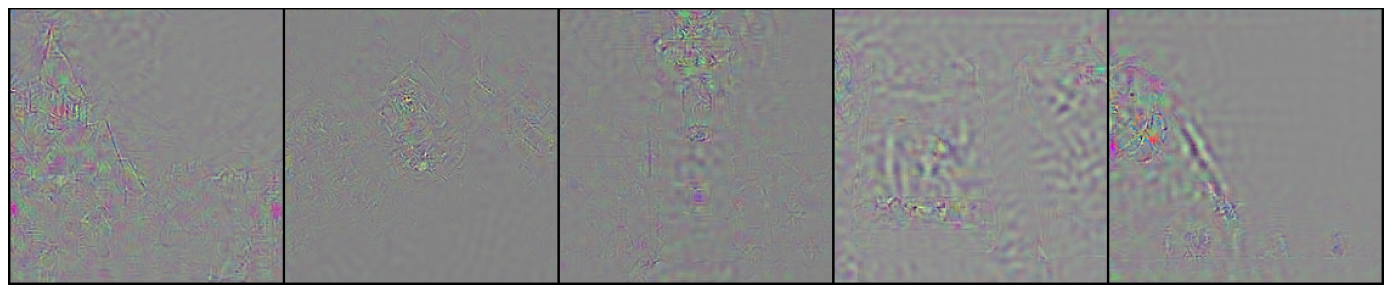

In [23]:
plot_example_grid(soft_grads, nrow=5)